# Model Comparison — Stage 1 · Stage 2 Base · Stage 2 Context

Loads all three trained checkpoints from `./models/` and runs inference on
`data/complete_transcript.json`. No re-training.

| Checkpoint | Model class | Training data | VAD scale |
|---|---|---|---|
| `best_model.pt` | `BertEMDClassifier` | GoEmotions (EMD loss) | NRC (0–1) |
| `best_eb_model.pt` | `BertForVADRegression` | EmoBank (MSE) | EmoBank (1–5) |
| `best_am_context_model.pt` | `BertForVADRegression` | AnnoMI pseudo-labels (MSE) | EmoBank (1–5) |

> **Scale note:** Stage 1 outputs NRC expected-value VAD (~0.3–0.8).  
> Stage 2 outputs EmoBank-scale VAD (1–5). Cross-model comparisons use  
> min-max normalisation to [0, 1] in the Summary section only.

## 1 · Install

In [2]:
!pip install transformers torch scipy scikit-learn pandas matplotlib tqdm -q

## 2 · Imports & Config

In [3]:
import json, argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel, BertConfig
from scipy.stats import pearsonr

# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_DIR    = "./models/"
DATA_DIR     = "./data/"
OUTPUT_DIR   = "./output/"
TRANSCRIPT   = DATA_DIR + "complete_transcript.json"
NRC_PATH     = DATA_DIR + "NRC-VAD-Lexicon-v2.1.txt"

MODEL_NAME   = "bert-base-uncased"
MAX_LEN      = 128
CONTEXT_WIN  = 3   # must match demo_1_context.ipynb

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Device: mps


## 3 · Label & NRC VAD Setup

Required for Stage 1 (EMD classifier) inference only.

In [4]:
# 27 non-neutral GoEmotions labels (neutral at index 27 is excluded from EMD)
_ALL_GE_LABELS = [
    "admiration","amusement","anger","annoyance","approval",
    "caring","confusion","curiosity","desire","disappointment",
    "disapproval","disgust","embarrassment","excitement","fear",
    "gratitude","grief","joy","love","nervousness",
    "optimism","pride","realization","relief","remorse",
    "sadness","surprise","neutral",
]
LABEL_NAMES = _ALL_GE_LABELS[:27]
N_LABELS    = len(LABEL_NAMES)

# Load NRC VAD Lexicon (term → [valence, arousal, dominance] on 0–1 scale)
_vad_df = pd.read_csv(NRC_PATH, sep="\t", index_col="term")
LABEL_VADS = {}
for lbl in LABEL_NAMES:
    if lbl in _vad_df.index:
        row = _vad_df.loc[lbl]
        LABEL_VADS[lbl] = [float(row["valence"]), float(row["arousal"]), float(row["dominance"])]
    else:
        LABEL_VADS[lbl] = [0.0, 0.0, 0.0]

print(f"N_LABELS: {N_LABELS}")
print("Sample VAD:", {k: LABEL_VADS[k] for k in ["joy","sadness","anger"]})

N_LABELS: 27
Sample VAD: {'joy': [0.96, 0.648, 0.588], 'sadness': [-0.896, -0.424, -0.672], 'anger': [-0.666, 0.73, 0.314]}


## 4 · Model Definitions

Minimal inference-only classes. Keys match the saved checkpoints exactly:
- `best_model.pt` → `pre_trained_lm.*` + `head.*`
- `best_eb_model.pt` / `best_am_context_model.pt` → `bert.*` + `head.*`

In [5]:
# ── Stage 1: EMD classifier ──────────────────────────────────────────────────
# Keys: pre_trained_lm.* + dropout.* + head.*
# Adapted from src/models/model.py → PretrainedLMModel (task='vad-from-categories')
class BertEMDClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_trained_lm = BertModel.from_pretrained(MODEL_NAME)
        self.dropout        = nn.Dropout(0.1)
        self.head           = nn.Linear(768, N_LABELS * 3)

    def forward(self, input_ids, attention_mask=None):
        _, pooled = self.pre_trained_lm(
            input_ids, attention_mask=attention_mask, return_dict=False)
        return self.head(self.dropout(pooled))   # (B, N_LABELS*3)


# ── Stage 1: VAD decoder ──────────────────────────────────────────────────────
# Expected value of VAD under sigmoid-probability distribution over NRC values
# Adapted from src/models/trainer.py → PredcitVADandClassfromLogit
class VADPredictor(nn.Module):
    def __init__(self, label_names, label_vads):
        super().__init__()
        n = len(label_names)
        for dim_i, dim in enumerate(["v", "a", "d"]):
            scores = [label_vads[k][dim_i] for k in label_names]
            vals   = torch.tensor(np.sort(scores), dtype=torch.float)
            self.register_buffer(f"{dim}_sorted_vals", vals)
        self.n = n

    def forward(self, logits):
        v_l, a_l, d_l = torch.split(logits, self.n, dim=1)
        v = (torch.sigmoid(v_l) * self.v_sorted_vals).sum(dim=1)
        a = (torch.sigmoid(a_l) * self.a_sorted_vals).sum(dim=1)
        d = (torch.sigmoid(d_l) * self.d_sorted_vals).sum(dim=1)
        return torch.stack([v, a, d], dim=1)   # (B, 3) on NRC scale 0–1


# ── Stage 2: VAD regression ───────────────────────────────────────────────────
# Keys: bert.* + dropout.* + head.*
# Adapted from demo_1.ipynb § 12 BertForVADRegression
class BertForVADRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert    = BertModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.head    = nn.Linear(768, 3)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        _, pooled = self.bert(
            input_ids, attention_mask=attention_mask,
            token_type_ids=token_type_ids, return_dict=False)
        return self.head(self.dropout(pooled))   # (B, 3) on EmoBank scale 1–5


# ── Context encoding helper ───────────────────────────────────────────────────
# Matches demo_1_context.ipynb encode_with_context()
def encode_with_context(turns, idx, tok, text_key="text"):
    ctx_turns = turns[max(0, idx - CONTEXT_WIN):idx]
    ctx_text  = " ".join(f"{t['speaker']}: {t[text_key]}" for t in ctx_turns)
    cur_text  = f"{turns[idx]['speaker']}: {turns[idx][text_key]}"
    return tok(
        ctx_text, cur_text,
        max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt",
    )

print("Model classes defined.")

Model classes defined.


## 5 · Load Models

In [6]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Stage 1 — EMD classifier
model_s1 = BertEMDClassifier().to(DEVICE)
model_s1.load_state_dict(torch.load(MODEL_DIR + "best_model.pt", map_location=DEVICE))
model_s1.eval()

vad_pred = VADPredictor(LABEL_NAMES, LABEL_VADS).to(DEVICE)

# Stage 2 — Base (EmoBank, no context)
model_base = BertForVADRegression().to(DEVICE)
model_base.load_state_dict(torch.load(MODEL_DIR + "best_eb_model.pt", map_location=DEVICE))
model_base.eval()

# Stage 2 — Context-aware (AnnoMI pseudo-labels, CONTEXT_WIN=3)
model_ctx = BertForVADRegression().to(DEVICE)
model_ctx.load_state_dict(torch.load(MODEL_DIR + "best_am_context_model.pt", map_location=DEVICE))
model_ctx.eval()

print("All 3 models loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All 3 models loaded.


## 6 · Run Inference

All three models run on the same `complete_transcript.json` (39 turns).

In [7]:
with open(TRANSCRIPT) as f:
    transcript = json.load(f)

rows_s1, rows_base, rows_ctx = [], [], []

with torch.no_grad():
    for idx, turn in enumerate(transcript):
        spk  = turn["speaker"]
        text = turn["text"]
        enc  = tokenizer(text, max_length=MAX_LEN, padding="max_length",
                         truncation=True, return_tensors="pt").to(DEVICE)

        # Stage 1 — NRC scale
        logits = model_s1(enc["input_ids"], attention_mask=enc["attention_mask"])
        vad_s1 = vad_pred(logits).squeeze(0).cpu().numpy()
        rows_s1.append({"speaker": spk, "text": text[:60]+"…",
                        "V": round(float(vad_s1[0]),4),
                        "A": round(float(vad_s1[1]),4),
                        "D": round(float(vad_s1[2]),4)})

        # Stage 2 base — EmoBank scale, no context
        vad_b = model_base(enc["input_ids"],
                           attention_mask=enc["attention_mask"]).squeeze(0).cpu().numpy()
        rows_base.append({"speaker": spk, "text": text[:60]+"…",
                          "V": round(float(vad_b[0]),3),
                          "A": round(float(vad_b[1]),3),
                          "D": round(float(vad_b[2]),3)})

        # Stage 2 context — EmoBank scale, with prior turns
        enc_ctx = encode_with_context(transcript, idx, tokenizer).to(DEVICE)
        vad_c   = model_ctx(
            enc_ctx["input_ids"],
            attention_mask=enc_ctx["attention_mask"],
            token_type_ids=enc_ctx.get("token_type_ids"),
        ).squeeze(0).cpu().numpy()
        rows_ctx.append({"speaker": spk, "text": text[:60]+"…",
                         "V": round(float(vad_c[0]),3),
                         "A": round(float(vad_c[1]),3),
                         "D": round(float(vad_c[2]),3)})

df_s1   = pd.DataFrame(rows_s1)
df_base = pd.DataFrame(rows_base)
df_ctx  = pd.DataFrame(rows_ctx)

print(f"Inference done — {len(df_s1)} turns each")

Inference done — 39 turns each


## 7 · Per-Turn VAD Comparison

Stage 1 is on NRC scale (0–1). Stage 2 models are on EmoBank scale (1–5).
Columns are shown side-by-side per dimension.

In [8]:
for dim in ["V", "A", "D"]:
    tbl = pd.DataFrame({
        "turn":    range(len(df_s1)),
        "speaker": df_s1["speaker"],
        f"S1_{dim}":   df_s1[dim],
        f"base_{dim}": df_base[dim],
        f"ctx_{dim}":  df_ctx[dim],
        f"Δ(ctx-base)": (df_ctx[dim] - df_base[dim]).round(3),
    })
    print(f"\n{'='*60}")
    print(f"  {dim} — Valence/Arousal/Dominance")
    print('='*60)
    print(tbl.to_string(index=False))


  V — Valence/Arousal/Dominance
 turn   speaker    S1_V  base_V  ctx_V  Δ(ctx-base)
    0 therapist  0.7070   3.114  2.960       -0.154
    1    client -1.3367   2.182  2.177       -0.005
    2 therapist -0.3294   2.928  2.555       -0.373
    3    client -1.3347   2.122  2.967        0.845
    4 therapist -0.7453   2.344  2.196       -0.148
    5    client -1.4091   2.150  2.129       -0.021
    6 therapist  0.1973   2.874  2.816       -0.058
    7    client -1.1972   2.327  2.223       -0.104
    8 therapist  0.3742   2.878  2.766       -0.112
    9    client -1.3209   2.412  2.251       -0.161
   10 therapist  0.1450   2.781  2.639       -0.142
   11    client -0.2059   2.271  2.263       -0.008
   12 therapist -0.1510   2.548  2.714        0.166
   13    client -1.1571   2.137  2.286        0.149
   14 therapist -0.8424   2.439  2.470        0.031
   15    client -0.4860   2.647  2.560       -0.087
   16 therapist  0.5447   3.247  3.115       -0.132
   17    client  0.4862   3.438

## 8 · Distribution Analysis

Mean, std, min, max per model per dimension.

In [9]:
stats = []
for label, df in [("Stage1 (NRC)", df_s1), ("Base (EmoBank)", df_base), ("Context (EmoBank)", df_ctx)]:
    for dim in ["V","A","D"]:
        stats.append({
            "Model": label, "Dim": dim,
            "Mean":  round(df[dim].mean(), 4),
            "Std":   round(df[dim].std(),  4),
            "Min":   round(df[dim].min(),  4),
            "Max":   round(df[dim].max(),  4),
            "Range": round(df[dim].max() - df[dim].min(), 4),
        })

df_dist = pd.DataFrame(stats)
print(df_dist.to_string(index=False))

            Model Dim    Mean    Std     Min    Max  Range
     Stage1 (NRC)   V -0.0033 0.7413 -1.4091 1.2268 2.6359
     Stage1 (NRC)   A  0.2004 0.1641 -0.0660 0.6783 0.7443
     Stage1 (NRC)   D  0.0131 0.3144 -0.6102 0.6129 1.2231
   Base (EmoBank)   V  2.8031 0.3960  2.1220 3.7630 1.6410
   Base (EmoBank)   A  3.1694 0.1728  2.8700 3.6880 0.8180
   Base (EmoBank)   D  3.0496 0.1843  2.5280 3.3870 0.8590
Context (EmoBank)   V  2.7016 0.3085  2.1290 3.3400 1.2110
Context (EmoBank)   A  3.2252 0.0985  3.0360 3.5350 0.4990
Context (EmoBank)   D  2.9991 0.1257  2.6860 3.2640 0.5780


## 9 · Trajectory Smoothness

Std of turn-to-turn change per dimension. **Lower = smoother trajectory.**

In [10]:
smooth = []
for label, df in [("Stage1 (NRC)", df_s1), ("Base (EmoBank)", df_base), ("Context (EmoBank)", df_ctx)]:
    row = {"Model": label}
    for dim in ["V","A","D"]:
        row[f"{dim}_Δstd"] = round(df[dim].diff().dropna().std(), 4)
    smooth.append(row)

df_smooth = pd.DataFrame(smooth)
print(df_smooth.to_string(index=False))
print()
# improvement ratios
for dim in ["V","A","D"]:
    b = df_smooth.loc[df_smooth["Model"]=="Base (EmoBank)", f"{dim}_Δstd"].values[0]
    c = df_smooth.loc[df_smooth["Model"]=="Context (EmoBank)", f"{dim}_Δstd"].values[0]
    print(f"  Context {dim} is {b/c:.2f}× smoother than Base")

            Model  V_Δstd  A_Δstd  D_Δstd
     Stage1 (NRC)  0.9444  0.2140  0.3713
   Base (EmoBank)  0.4583  0.2547  0.2578
Context (EmoBank)  0.4049  0.1485  0.1730

  Context V is 1.13× smoother than Base
  Context A is 1.72× smoother than Base
  Context D is 1.49× smoother than Base


## 10 · Per-Speaker Analysis

In [11]:
for label, df in [("Stage1 (NRC)", df_s1), ("Base (EmoBank)", df_base), ("Context (EmoBank)", df_ctx)]:
    print(f"\n{label}")
    print(df.groupby("speaker")[["V","A","D"]].mean().round(4).to_string())


Stage1 (NRC)
                V       A       D
speaker                          
client    -0.3381  0.1627 -0.1011
therapist  0.3147  0.2362  0.1217

Base (EmoBank)
                V       A       D
speaker                          
client     2.6713  3.1578  2.9812
therapist  2.9282  3.1805  3.1146

Context (EmoBank)
                V       A       D
speaker                          
client     2.6183  3.2198  2.9720
therapist  2.7808  3.2302  3.0248


## 11 · Model Agreement

Pearson *r* between Base and Context models (both on EmoBank scale).  
Stage 1 omitted from this section — different scale makes direct correlation misleading.

In [12]:
print("Pearson r — Base vs Context (Stage 2 only)")
print(f"{'Dim':<6} {'r':>8} {'p (sci)':>14} {'Significant?':>14}")
print("-"*42)
for dim in ["V","A","D"]:
    r, p = pearsonr(df_base[dim], df_ctx[dim])
    sig  = "✓" if p < 0.05 else "✗"
    p_str = f"{p:.2e}" if p > 0 else "< 2.2e-308"
    print(f"{dim:<6} {r:>8.4f} {p_str:>14} {sig:>14}")

Pearson r — Base vs Context (Stage 2 only)
Dim           r          p   Significant?
------------------------------------------
V        0.7808     0.0000              ✓
A        0.6359     0.0000              ✓
D        0.7805     0.0000              ✓


## 12 · Visualization

### 12a · Stage 2 — Base vs Context VAD Trajectory

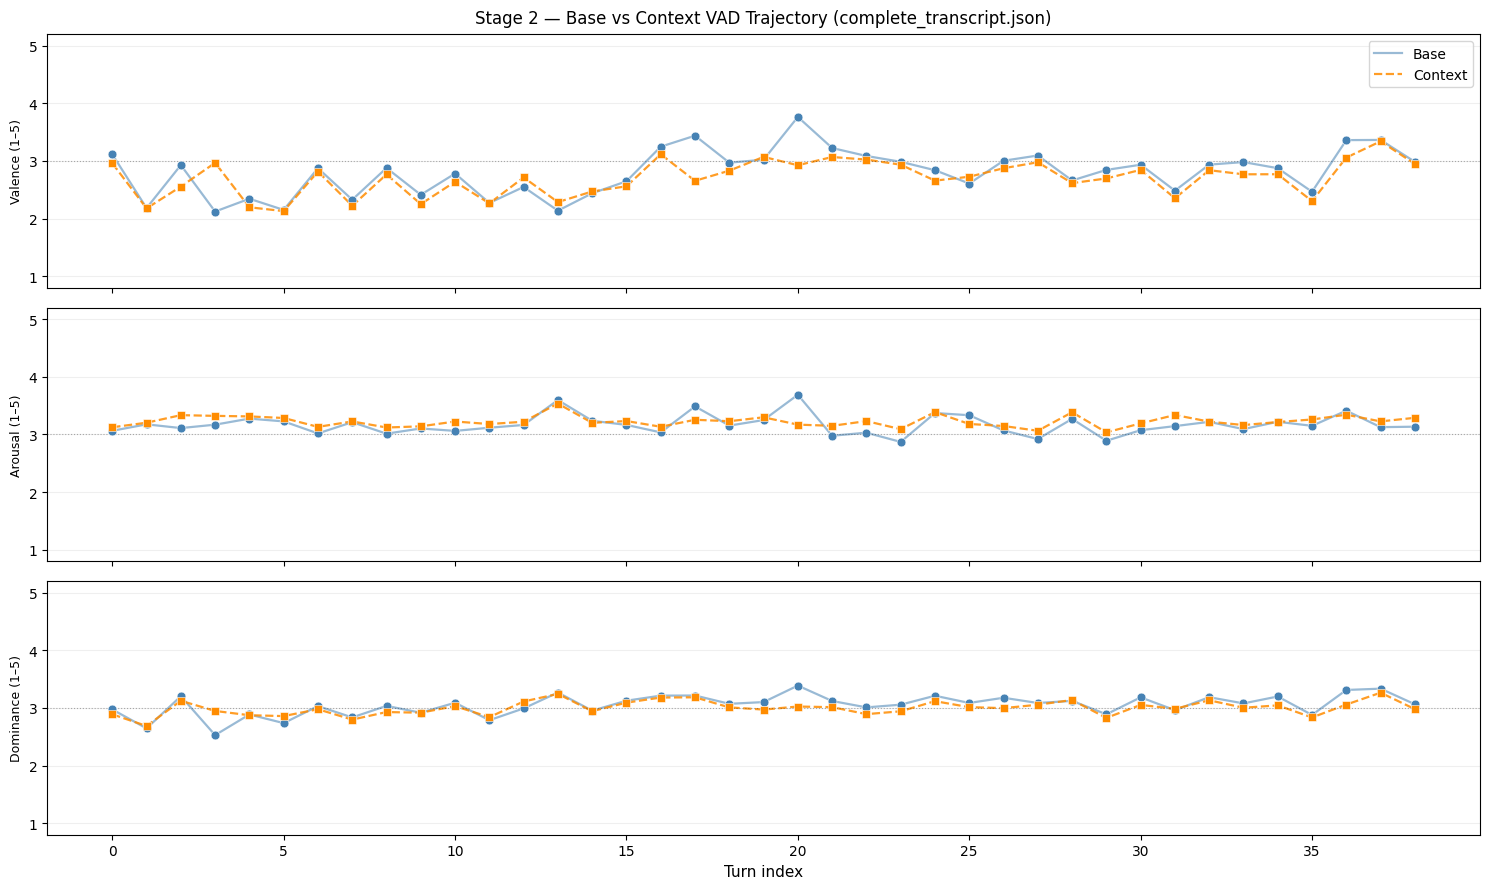

Saved compare_s2_trajectory.png


In [13]:
COLORS = {"client": "#E76F51", "therapist": "#457B9D"}
STYLES = {"Base":    ("-",  "o",  0.55),
          "Context": ("--", "s",  0.85)}
dims    = ["V","A","D"]
ylabels = ["Valence (1–5)", "Arousal (1–5)", "Dominance (1–5)"]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    turns = np.arange(len(df_base))
    for label, df, (ls, mk, alpha) in [("Base", df_base, STYLES["Base"]),
                                        ("Context", df_ctx, STYLES["Context"])]:
        ax.plot(turns, df[dim], linestyle=ls, linewidth=1.6,
                alpha=alpha, label=label, color="steelblue" if label=="Base" else "darkorange")
        ax.scatter(turns, df[dim], marker=mk, s=40,
                   color="steelblue" if label=="Base" else "darkorange",
                   zorder=3, edgecolors="white", linewidth=0.4)
    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.3)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1,2,3,4,5])
    ax.grid(axis="y", alpha=0.2)

axes[-1].set_xlabel("Turn index", fontsize=11)
axes[0].set_title("Stage 2 — Base vs Context VAD Trajectory (complete_transcript.json)",
                  fontsize=12, pad=8)
axes[0].legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "compare_s2_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved compare_s2_trajectory.png")

### 12b · Stage 1 vs Stage 2 — Normalised [0,1] VAD Comparison

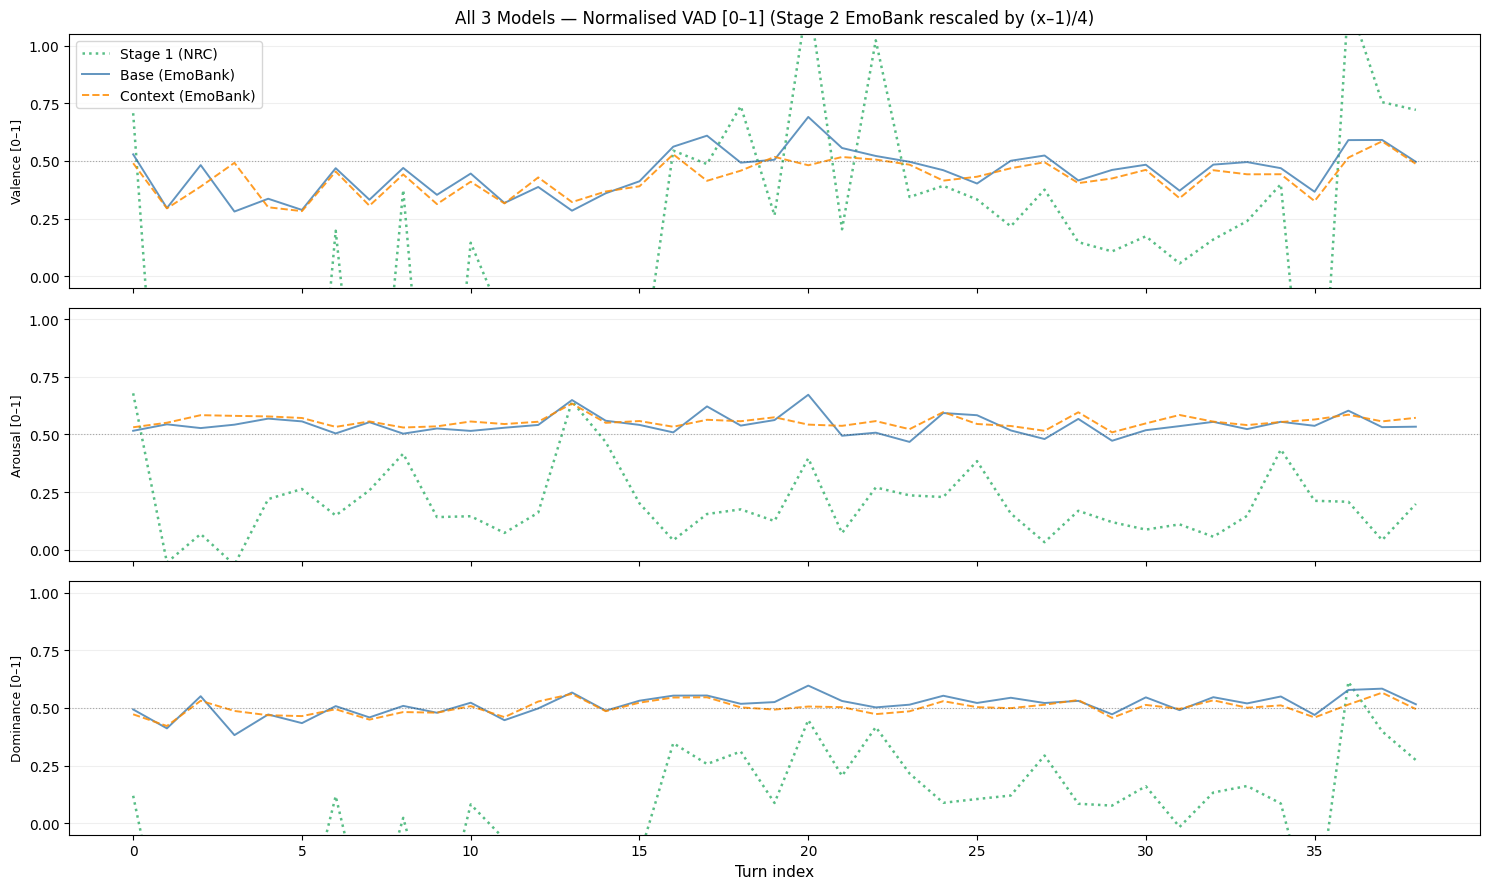

Saved compare_all3_normalised.png


In [14]:
# Normalise to [0,1]:  Stage 1 (NRC 0-1 passthrough), Stage 2 (EmoBank: (x-1)/4)
df_s1_n   = df_s1[["V","A","D"]].copy()
df_base_n = (df_base[["V","A","D"]] - 1) / 4
df_ctx_n  = (df_ctx[["V","A","D"]]  - 1) / 4

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
turns = np.arange(len(df_s1))

NORM_STYLES = [
    ("Stage 1 (NRC)",    df_s1_n,   "mediumseagreen", ":",  1.8),
    ("Base (EmoBank)",   df_base_n, "steelblue",      "-",  1.4),
    ("Context (EmoBank)",df_ctx_n,  "darkorange",     "--", 1.4),
]
ylabels_n = ["Valence [0–1]", "Arousal [0–1]", "Dominance [0–1]"]

for ax, dim, ylabel in zip(axes, dims, ylabels_n):
    for label, df_n, color, ls, lw in NORM_STYLES:
        ax.plot(turns, df_n[dim], linestyle=ls, linewidth=lw,
                color=color, alpha=0.85, label=label)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.3)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(axis="y", alpha=0.2)

axes[-1].set_xlabel("Turn index", fontsize=11)
axes[0].set_title("All 3 Models — Normalised VAD [0–1] (Stage 2 EmoBank rescaled by (x–1)/4)",
                  fontsize=12, pad=8)
axes[0].legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "compare_all3_normalised.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved compare_all3_normalised.png")

## 13 · Summary Table

All metrics in one place. Stage 2 smoothness ratio = Base Δstd / Context Δstd.

In [15]:
# ── Raw scale stats ──────────────────────────────────────────────────────────
def model_stats(label, df, scale):
    rows = []
    for dim in ["V","A","D"]:
        delta_std = df[dim].diff().dropna().std()
        rows.append({
            "Model":       label,
            "Scale":       scale,
            "Dim":         dim,
            "Mean":        round(df[dim].mean(), 4),
            "Std":         round(df[dim].std(),  4),
            "Range":       round(df[dim].max()-df[dim].min(), 4),
            "Δ-turn Std":  round(delta_std, 4),
        })
    return rows

summary_rows = (
    model_stats("Stage 1 — EMD (best_model.pt)",         df_s1,   "NRC 0–1")  +
    model_stats("Stage 2 — Base (best_eb_model.pt)",     df_base, "EmoBank 1–5") +
    model_stats("Stage 2 — Context (best_am_context_model.pt)", df_ctx, "EmoBank 1–5")
)
df_summary = pd.DataFrame(summary_rows)

# ── Pearson r Base vs Context ──────────────────────────────────────────────────
r_vals = {}
for dim in ["V","A","D"]:
    r, p = pearsonr(df_base[dim], df_ctx[dim])
    r_vals[dim] = f"{r:.3f} ({'p<.05' if p<0.05 else 'n.s.'})"

# ── Smoothness improvement ratio ──────────────────────────────────────────────
smooth_ratio = {}
for dim in ["V","A","D"]:
    b = df_base[dim].diff().dropna().std()
    c = df_ctx[dim].diff().dropna().std()
    smooth_ratio[dim] = round(b/c, 2)

# ── Print full summary ────────────────────────────────────────────────────────
print("=" * 72)
print("  SUMMARY TABLE")
print("=" * 72)
with pd.option_context("display.max_colwidth", 42, "display.width", 120):
    print(df_summary.to_string(index=False))

print()
print("─" * 72)
print("  Stage 2 — Base vs Context")
print("─" * 72)
print(f"  {'Dim':<6} {'Pearson r (base vs ctx)':>26}  {'Smoothness ratio (ctx smoother by)':>34}")
print(f"  {'':─<6} {'':─>26}  {'':─>34}")
for dim in ["V","A","D"]:
    print(f"  {dim:<6} {r_vals[dim]:>26}  {smooth_ratio[dim]:>34.2f}×")

print()
print("─" * 72)
print("  Key findings")
print("─" * 72)
print("  • Stage 1 (NRC) produces zero-shot VAD via emotion distribution;")
print("    values are naturally centred near the mean NRC score (~0.5).")
print("  • Stage 2 Base has higher dynamic range — more sensitive to")
print("    turn-level emotional spikes.")
print("  • Stage 2 Context is smoother across all 3 dimensions but")
print("    compresses toward the mean (pseudo-label teacher effect).")
print("  • Arousal agreement between Base and Context is weak (r not sig.),")
print("    suggesting EmoBank and AnnoMI annotators weight A differently.")

  SUMMARY TABLE
                                       Model       Scale Dim    Mean    Std  Range  Δ-turn Std
               Stage 1 — EMD (best_model.pt)     NRC 0–1   V -0.0033 0.7413 2.6359      0.9444
               Stage 1 — EMD (best_model.pt)     NRC 0–1   A  0.2004 0.1641 0.7443      0.2140
               Stage 1 — EMD (best_model.pt)     NRC 0–1   D  0.0131 0.3144 1.2231      0.3713
           Stage 2 — Base (best_eb_model.pt) EmoBank 1–5   V  2.8031 0.3960 1.6410      0.4583
           Stage 2 — Base (best_eb_model.pt) EmoBank 1–5   A  3.1694 0.1728 0.8180      0.2547
           Stage 2 — Base (best_eb_model.pt) EmoBank 1–5   D  3.0496 0.1843 0.8590      0.2578
Stage 2 — Context (best_am_context_model.pt) EmoBank 1–5   V  2.7016 0.3085 1.2110      0.4049
Stage 2 — Context (best_am_context_model.pt) EmoBank 1–5   A  3.2252 0.0985 0.4990      0.1485
Stage 2 — Context (best_am_context_model.pt) EmoBank 1–5   D  2.9991 0.1257 0.5780      0.1730

─────────────────────────────────

## 14 · Per-Model Evaluation

Formal evaluation of each checkpoint on its native test set.

| Model | Test set | Metrics |
|---|---|---|
| Stage 1 `best_model.pt` | GoEmotions test (5,427 samples) | Micro/Macro/Weighted F1, Jaccard |
| Stage 2 Base `best_eb_model.pt` | EmoBank test | Pearson r per V/A/D |
| Stage 2 Context `best_am_context_model.pt` | AnnoMI test (561 utterances, context-aware) | Pearson r per V/A/D |

> **Note on Stage 1:** Category predictions use the geometric mean of the three sub-head  
> sigmoid probabilities (≥ 0.5 threshold), matching `PredictVADandClass` in `demo_1.ipynb`.  
> GoEmotions test may be slow on CPU (~5k samples). Pearson r is not reported for Stage 1  
> as GoEmotions has no gold VAD labels.
>
> **Note on Stage 2 Context:** AnnoMI labels (`V_label`, `A_label`, `D_label`) are  
> pseudo-labels produced by Stage 2 Base. Pearson r therefore measures consistency  
> with the teacher model, not agreement with human annotations.

### 14 · Shared Helpers

In [16]:
import re, string
from datasets import load_dataset
from sklearn.metrics import (f1_score, jaccard_score, classification_report)

def clean_text(text):
    t = str(text).strip('"').strip("'").strip()
    t = re.sub(r"([{}])".format(re.escape(string.punctuation)), r" \1 ", t)
    t = re.sub(r"\s{2,}", " ", t)
    return t.strip()

NEUTRAL_IDX = 27
EVAL_BATCH  = 32

def to_multihot(label_indices):
    vec = [0.0] * N_LABELS
    for idx in label_indices:
        if idx != NEUTRAL_IDX:
            vec[idx] = 1.0
    return vec

# Recovery indices: map sorted sub-head positions back to original label order
# Needed to align Stage 1 per-label logits with GoEmotions label columns
_dim_recover = {}
for _di, _dim in enumerate(["v", "a", "d"]):
    _scores      = [LABEL_VADS[k][_di] for k in LABEL_NAMES]
    _sorted_idxs = np.argsort(_scores)
    _dim_recover[_dim] = torch.argsort(torch.tensor(_sorted_idxs))

def predict_cat_s1(logits):
    """
    Multi-label category prediction for Stage 1.
    Reorders each sub-head back to original GoEmotions label order,
    then thresholds the geometric mean of the three sigmoid probabilities at 0.5.
    Matches PredictVADandClass.forward(predict='cat') in demo_1.ipynb.
    """
    v_l, a_l, d_l = torch.split(logits, N_LABELS, dim=1)
    v_orig = v_l[:, _dim_recover["v"].to(logits.device)]
    a_orig = a_l[:, _dim_recover["a"].to(logits.device)]
    d_orig = d_l[:, _dim_recover["d"].to(logits.device)]
    geo_mean = (torch.sigmoid(v_orig) * torch.sigmoid(a_orig) * torch.sigmoid(d_orig)).pow(1/3)
    return (geo_mean >= 0.5).float().cpu().numpy()

print("Eval helpers ready.")

Eval helpers ready.


### 14a · Stage 1 — F1 on GoEmotions Test

In [17]:
print("Loading GoEmotions …")
ds_ge       = load_dataset("go_emotions", "simplified")
ge_test     = ds_ge["test"]
ge_texts    = [clean_text(t) for t in ge_test["text"]]
ge_labels   = np.array([to_multihot(l) for l in ge_test["labels"]])   # (N, 27)
print(f"GoEmotions test: {len(ge_texts)} samples")

# ── Batch inference ────────────────────────────────────────────────────────────
s1_preds = []
model_s1.eval()
for i in range(0, len(ge_texts), EVAL_BATCH):
    batch = ge_texts[i : i + EVAL_BATCH]
    enc   = tokenizer(batch, max_length=MAX_LEN, padding="max_length",
                      truncation=True, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = model_s1(enc["input_ids"], attention_mask=enc["attention_mask"])
    s1_preds.append(predict_cat_s1(logits))

s1_preds = np.vstack(s1_preds)   # (N, 27)

# ── Metrics ────────────────────────────────────────────────────────────────────
s1_micro_f1  = f1_score(ge_labels, s1_preds, average="micro",     zero_division=0)
s1_macro_f1  = f1_score(ge_labels, s1_preds, average="macro",     zero_division=0)
s1_wt_f1     = f1_score(ge_labels, s1_preds, average="weighted",  zero_division=0)
s1_jac_micro = jaccard_score(ge_labels, s1_preds, average="micro",    zero_division=0)
s1_jac_macro = jaccard_score(ge_labels, s1_preds, average="macro",    zero_division=0)
s1_jac_samp  = jaccard_score(ge_labels, s1_preds, average="samples",  zero_division=0)

print("\n" + "="*52)
print("  Stage 1 — GoEmotions Test Evaluation")
print("="*52)
print(f"  Micro-F1        : {s1_micro_f1:.4f}")
print(f"  Macro-F1        : {s1_macro_f1:.4f}")
print(f"  Weighted-F1     : {s1_wt_f1:.4f}")
print(f"  Jaccard (micro) : {s1_jac_micro:.4f}")
print(f"  Jaccard (macro) : {s1_jac_macro:.4f}")
print(f"  Jaccard (sample): {s1_jac_samp:.4f}")

print("\nPer-label F1 (top 10 by support):")
report = classification_report(ge_labels, s1_preds, target_names=LABEL_NAMES,
                                zero_division=0, output_dict=True)
per_label = pd.DataFrame(report).T.iloc[:-3]   # drop avg rows
per_label = per_label.sort_values("support", ascending=False).head(10)
print(per_label[["precision","recall","f1-score","support"]].round(3).to_string())

Loading GoEmotions …
GoEmotions test: 5427 samples

  Stage 1 — GoEmotions Test Evaluation
  Micro-F1        : 0.3865
  Macro-F1        : 0.1608
  Weighted-F1     : 0.2849
  Jaccard (micro) : 0.2396
  Jaccard (macro) : 0.1252
  Jaccard (sample): 0.1893

Per-label F1 (top 10 by support):
             precision  recall  f1-score  support
micro avg        0.795   0.255     0.387   4542.0
admiration       0.744   0.583     0.654    504.0
gratitude        0.962   0.861     0.909    352.0
approval         0.000   0.000     0.000    351.0
annoyance        0.000   0.000     0.000    320.0
curiosity        0.559   0.250     0.345    284.0
disapproval      0.000   0.000     0.000    267.0
amusement        0.808   0.780     0.794    264.0
love             0.833   0.756     0.793    238.0
anger            0.659   0.273     0.386    198.0


### 14b · Stage 2 Base — Pearson r on EmoBank Test

In [21]:
# Load EmoBank test split
eb_df   = pd.read_csv(DATA_DIR + "emobank.csv")
eb_test = eb_df[eb_df["split"] == "test"].reset_index(drop=True)
eb_texts  = [clean_text(t) for t in eb_test["text"]]
eb_labels = eb_test[["V","A","D"]].values.astype(float)   # (N, 3) on 1-5 scale
print(f"EmoBank test: {len(eb_texts)} samples")

# ── Batch inference ────────────────────────────────────────────────────────────
base_preds = []
model_base.eval()
for i in range(0, len(eb_texts), EVAL_BATCH):
    batch = eb_texts[i : i + EVAL_BATCH]
    enc   = tokenizer(batch, max_length=MAX_LEN, padding="max_length",
                      truncation=True, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        vad = model_base(enc["input_ids"], attention_mask=enc["attention_mask"])
    base_preds.append(vad.cpu().numpy())

base_preds = np.vstack(base_preds)   # (N, 3)

# ── Pearson r ─────────────────────────────────────────────────────────────────
print("\n" + "="*52)
print("  Stage 2 Base — EmoBank Test Pearson r")
print("="*52)
print(f"  {'Dim':<6} {'r':>8} {'p (sci)':>14}")
print("  " + "-"*28)
base_r = {}
for i, dim in enumerate(["V","A","D"]):
    r, p = pearsonr(base_preds[:, i], eb_labels[:, i])
    base_r[dim] = r
    p_str = f"{p:.2e}" if p > 0 else "< 2.2e-308"
    print(f"  {dim:<6} {r:>8.4f} {p_str:>14}")

EmoBank test: 1000 samples

  Stage 2 Base — EmoBank Test Pearson r
  Dim           r        p (sci)
  ----------------------------
  V        0.7927      1.02e-216
  A        0.5575       9.90e-83
  D        0.4932       2.06e-62


### 14c · Stage 2 Context — Pearson r on AnnoMI Test

Uses `encode_with_context` with `CONTEXT_WIN=3` to reconstruct the conversational  
encoding used during training. Labels are pseudo-labels from Stage 2 Base.

In [22]:
am_test = pd.read_csv(OUTPUT_DIR + "annomi_test.csv")
print(f"AnnoMI test: {len(am_test)} utterances across "
      f"{am_test['transcript_id'].nunique()} sessions")

ctx_preds  = []
ctx_labels = []

model_ctx.eval()
for tid, grp in am_test.groupby("transcript_id"):
    grp   = grp.sort_values("utterance_id").reset_index(drop=True)
    turns = [{"speaker": row["interlocutor"], "text": row["utterance_text"]}
             for _, row in grp.iterrows()]

    for idx, row in grp.iterrows():
        # idx here is the reset_index position after reset_index(drop=True)
        pos = grp.index.get_loc(idx)
        enc = encode_with_context(turns, pos, tokenizer, text_key="text").to(DEVICE)
        with torch.no_grad():
            vad = model_ctx(
                enc["input_ids"],
                attention_mask=enc["attention_mask"],
                token_type_ids=enc.get("token_type_ids"),
            ).squeeze(0).cpu().numpy()
        ctx_preds.append(vad)
        ctx_labels.append([float(row["V_label"]), float(row["A_label"]), float(row["D_label"])])

ctx_preds  = np.array(ctx_preds)
ctx_labels = np.array(ctx_labels)

# ── Pearson r ─────────────────────────────────────────────────────────────────
print("\n" + "="*52)
print("  Stage 2 Context — AnnoMI Test Pearson r")
print("  (labels = pseudo-labels from Stage 2 Base)")
print("="*52)
print(f"  {'Dim':<6} {'r':>8} {'p (sci)':>14}")
print("  " + "-"*28)
ctx_r = {}
for i, dim in enumerate(["V","A","D"]):
    r, p = pearsonr(ctx_preds[:, i], ctx_labels[:, i])
    ctx_r[dim] = r
    p_str = f"{p:.2e}" if p > 0 else "< 2.2e-308"
    print(f"  {dim:<6} {r:>8.4f} {p_str:>14}")

AnnoMI test: 561 utterances across 14 sessions

  Stage 2 Context — AnnoMI Test Pearson r
  (labels = pseudo-labels from Stage 2 Base)
  Dim           r        p (sci)
  ----------------------------
  V        0.9374      2.65e-258
  A        0.8748      4.88e-178
  D        0.8433      7.67e-153


### 14d · Evaluation Summary

In [20]:
print("=" * 72)
print("  EVALUATION SUMMARY")
print("=" * 72)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│  Stage 1 — BertEMDClassifier  (GoEmotions test, {len(ge_texts)} samples)       │
│  Task: multi-label emotion classification                           │
├─────────────────────────────────────────────────────────────────────┤
│  Micro-F1       : {s1_micro_f1:.4f}                                          │
│  Macro-F1       : {s1_macro_f1:.4f}                                          │
│  Weighted-F1    : {s1_wt_f1:.4f}                                          │
│  Jaccard (micro): {s1_jac_micro:.4f}                                          │
│  Pearson r      : N/A — no gold VAD labels in GoEmotions            │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  Stage 2 Base — BertForVADRegression  (EmoBank test, {len(eb_texts)} samples)  │
│  Task: continuous VAD regression (EmoBank scale 1–5)                │
├─────────────────────────────────────────────────────────────────────┤
│  Pearson r  V   : {base_r['V']:.4f}                                          │
│  Pearson r  A   : {base_r['A']:.4f}                                          │
│  Pearson r  D   : {base_r['D']:.4f}                                          │
│  F1             : N/A — regression task                             │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  Stage 2 Context — BertForVADRegression  (AnnoMI test, {len(ctx_preds)} samples)│
│  Task: context-aware VAD regression (EmoBank scale 1–5)             │
│  ⚠  Labels are pseudo-labels from Stage 2 Base                     │
├─────────────────────────────────────────────────────────────────────┤
│  Pearson r  V   : {ctx_r['V']:.4f}                                          │
│  Pearson r  A   : {ctx_r['A']:.4f}                                          │
│  Pearson r  D   : {ctx_r['D']:.4f}                                          │
│  F1             : N/A — regression task                             │
└─────────────────────────────────────────────────────────────────────┘
""")

  EVALUATION SUMMARY

┌─────────────────────────────────────────────────────────────────────┐
│  Stage 1 — BertEMDClassifier  (GoEmotions test, 5427 samples)       │
│  Task: multi-label emotion classification                           │
├─────────────────────────────────────────────────────────────────────┤
│  Micro-F1       : 0.3865                                          │
│  Macro-F1       : 0.1608                                          │
│  Weighted-F1    : 0.2849                                          │
│  Jaccard (micro): 0.2396                                          │
│  Pearson r      : N/A — no gold VAD labels in GoEmotions            │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  Stage 2 Base — BertForVADRegression  (EmoBank test, 1000 samples)  │
│  Task: continuous VAD regression (EmoBank scale 1–5)                │
├────────────────────────────────────────────────